In [2]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import re

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data = {
    'Review': [
        'This product is amazing',
        'I love this phone',
        'Excellent quality',
        'Very happy with the purchase',
        'Worst product ever',
        'Waste of money',
        'Very disappointed',
        'Bad quality item',
        'Fantastic service',
        'Highly recommended'],
    'Sentiment': [
        'Positive',
        'Positive',
        'Positive',
        'Positive',
        'Negative',
        'Negative',
        'Negative',
        'Negative',
        'Positive',
        'Positive']
}

df = pd.DataFrame(data)
print(df.head())

                         Review Sentiment
0       This product is amazing  Positive
1             I love this phone  Positive
2             Excellent quality  Positive
3  Very happy with the purchase  Positive
4            Worst product ever  Negative


In [5]:
print(df.info())
print(df['Sentiment'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Review     10 non-null     object
 1   Sentiment  10 non-null     object
dtypes: object(2)
memory usage: 292.0+ bytes
None
Sentiment
Positive    6
Negative    4
Name: count, dtype: int64


In [6]:
print(df.isnull().sum())

Review       0
Sentiment    0
dtype: int64


In [7]:
stop_words = set(stopwords.words('english'))
print(stop_words)

{'here', 'what', 'should', 'of', 'during', 'those', 'itself', 'some', 'mustn', "they'd", 'through', 'whom', 'such', 'just', 'which', 'own', "haven't", 't', 'ours', 'before', 'shouldn', 'me', 's', 'the', 'who', 'does', 'll', 'above', 'been', "didn't", 'few', 'up', "we've", 'in', 'its', 'now', 'yours', "wouldn't", 'hers', "it's", 'against', 'out', 'then', "he'll", "i'd", 'only', 'how', 'nor', 'is', 'their', 'we', 'had', 'hasn', "it'd", "i've", 'hadn', "should've", 'were', 'that', "you've", 'themselves', 'didn', 'they', 'was', "they've", 've', 'won', "won't", 'he', 'at', "isn't", 'over', 'than', "they're", "i'll", 'yourself', 'not', 'him', 'all', 'once', 'shan', 'has', 'wouldn', 'both', "needn't", "that'll", 'no', 'y', 'and', 'couldn', 'there', 'did', "you'll", 'wasn', "we're", 'with', "she'll", 'mightn', 'her', 'my', "shouldn't", 'needn', 'i', 'ourselves', 'so', 'these', 'be', 'between', "we'd", 'herself', "weren't", 'why', 'doesn', 'again', 'by', "they'll", "hasn't", "i'm", 'most', 'whe

In [12]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [word for word in words
             if word not in stop_words]

    return " ".join(words)


df['Clean_Review'] = df['Review'].apply(clean_text)
print(df[['Review', 'Clean_Review']])

                         Review        Clean_Review
0       This product is amazing     product amazing
1             I love this phone          love phone
2             Excellent quality   excellent quality
3  Very happy with the purchase      happy purchase
4            Worst product ever  worst product ever
5                Waste of money         waste money
6             Very disappointed        disappointed
7              Bad quality item    bad quality item
8             Fantastic service   fantastic service
9            Highly recommended  highly recommended


In [16]:
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['Clean_Review'])
y = df['Sentiment']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,)
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(8, 19)
(2, 19)
(8,)
(2,)


In [25]:
model = MultinomialNB()
model.fit(X_train, y_train)
print("Model Trained Successfully \n")

y_pred = model.predict(X_test)
print("Predictions:")
print(y_pred)

results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred})

print(results)

Model Trained Successfully 

Predictions:
['Positive' 'Positive']
     Actual Predicted
8  Positive  Positive
1  Positive  Positive


In [26]:
new_review = ["This product is amazing"]
clean_review = clean_text(new_review[0])
review_vector = tfidf.transform([clean_review])
prediction = model.predict(review_vector)
print("Custom Review Prediction:")
print(prediction)

Custom Review Prediction:
['Positive']


In [29]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=['Positive', 'Negative']
)

print(cm)

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

    Positive       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

[[2 0]
 [0 0]]


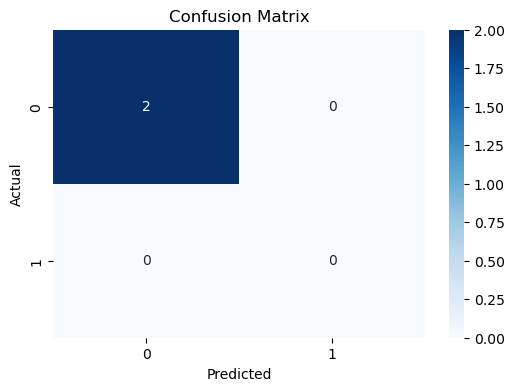

In [30]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [32]:
print("NLP Sentiment Analysis Project Completed Successfully")

print("""
Project Summary
---------------
1. Loaded text review dataset
2. Cleaned text using regex and stopwords
3. Converted text to numerical features using TF-IDF
4. Split data into training and testing sets
5. Trained a Multinomial Naive Bayes classifier
6. Predicted sentiments on test data
7. Evaluated using Accuracy, Classification Report, and Confusion Matrix
""")

NLP Sentiment Analysis Project Completed Successfully

Project Summary
---------------
1. Loaded text review dataset
2. Cleaned text using regex and stopwords
3. Converted text to numerical features using TF-IDF
4. Split data into training and testing sets
5. Trained a Multinomial Naive Bayes classifier
6. Predicted sentiments on test data
7. Evaluated using Accuracy, Classification Report, and Confusion Matrix

